# Masterclass: ReAct Agent (Reasoning + Acting) with Tool Calling in LangGraph

Welcome to the comprehensive guide on building a **ReAct Agent** (Reasoning + Acting) in **LangGraph**.

---

### Table of Contents / Interactive Index

- [1. Setup & Environment Verification](#1-setup--environment-verification)
- [2. Imports & Dependencies](#2-imports--dependencies)
- [3. Defining Custom Tools (`@tool`)](#3-defining-custom-tools-tool)
  - [3.1 Aggregating Tools into a List](#31-aggregating-tools-into-a-list)
- [4. Model Setup & Tool Binding (`bind_tools`)](#4-model-setup--tool-binding-bind_tools)
- [5. Agent System Instruction (`SystemMessage`)](#5-agent-system-instruction-systemmessage)
- [6. Building the LangGraph ReAct State Graph](#6-building-the-langgraph-react-state-graph)
  - [6.1 Wiring Graph Edges & Conditional Routing](#61-wiring-graph-edges--conditional-routing)
  - [6.2 Graph Visualization (`draw_mermaid_png`)](#62-graph-visualization-draw_mermaid_png)
- [7. Multi-Step Execution & Reasoning-Acting Trace](#7-multi-step-execution--reasoning-acting-trace)
  - [7.1 Formatted Execution Trajectory Inspection](#71-formatted-execution-trajectory-inspection)
  - [7.2 Final Output Display](#72-final-output-display)
- [8. Deep-Dive: Under the Hood of `tools_condition` & `AIMessage`](#8-deep-dive-under-the-hood-of-tools_condition--aimessage)
  - [8.1 How `tools_condition` Works Under the Hood](#81-how-tools_condition-works-under-the-hood)
  - [8.2 Anatomical Structure of `AIMessage` with `tool_calls`](#82-anatomical-structure-of-aimessage-with-tool_calls)
- [9. Deterministic ReAct Agent via Pydantic Tool Registry](#9-deterministic-react-agent-via-pydantic-tool-registry)

---

### The ReAct Paradigm (Yao et al., 2022)

The **ReAct (Reasoning and Acting)** framework enables LLMs to solve complex, multi-step problems by alternating between **Reasoning** (generating thought traces) and **Acting** (executing external tool calls).

```text
                                     START
                                       │
                                       ▼
                              [llm_node] (Reasoning)
                                       │
                    Model generates AIMessage (Thought + Tool Calls)
                                       │
                                       ▼
                             tools_condition (Router)
                              /                \
                       (YES) /                  \ (NO)
                            ▼                    ▼
                   [ToolNode] (Acting)          END (Final Answer)
                            │
                            └──► Returns ToolMessage outputs
                                 back to [llm_node] (Cyclic Loop)
```

---

### ReAct Loop Execution Trajectory

1. **User Prompt**: Input calculation or multi-hop question.
2. **Thought & Action (LLM)**: LLM inspects available tools and decides: *"I need to call tool X with arguments Y"*. Emits `AIMessage(tool_calls=[...])`.
3. **Observation (ToolNode)**: LangGraph `ToolNode` executes the Python function locally and appends `ToolMessage(content=result)`.
4. **Iterative Reasoning (LLM)**: LLM receives `ToolMessage`, observes the result, and either calls the next tool or produces the final answer.
5. **Completion**: When no further tool calls are generated, `tools_condition` routes to `END`.

<a id="1-setup--environment-verification"></a>
## 1. Setup & Environment Verification
Load environment variables from `.env` and verify API keys.

In [26]:
# Load environment variables from .env file
from dotenv import load_dotenv
load_dotenv()

True

<a id="2-imports--dependencies"></a>
## 2. Imports & Dependencies
Import LangChain message classes (`HumanMessage`, `SystemMessage`, `AIMessage`, `ToolMessage`) and LangGraph primitives (`StateGraph`, `MessagesState`, `ToolNode`, `tools_condition`).

In [27]:
# ============================================================
# 1. IMPORTS
# ============================================================

from langchain_groq import ChatGroq
from langchain_core.tools import tool

from langchain_core.messages import (
    HumanMessage,
    SystemMessage,
    AIMessage,
    ToolMessage,
)

from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END,
)

from langgraph.prebuilt import (
    ToolNode,
    tools_condition,
)

<a id="3-defining-custom-tools-tool"></a>
## 3. Defining Custom Tools (`@tool`)

We define 5 standalone Python functions for mathematical operations (`add`, `multiply`, `subtract`, `divide`, `power`) and decorate them with `@tool` so LangChain automatically generates parameter JSON schemas and descriptions.

In [28]:
# ============================================================
# 2. CREATE 5 TOOLS
# ============================================================


# ---------------------------
# TOOL 1
# ---------------------------

@tool
def add(a: float, b: float) -> float:
    """
    Add two numbers.
    Use this tool whenever two numbers need to be added.
    """

    return a + b


# ---------------------------
# TOOL 2
# ---------------------------

@tool
def multiply(a: float, b: float) -> float:
    """
    Multiply two numbers.
    Use this tool whenever multiplication is required.
    """

    return a * b


# ---------------------------
# TOOL 3
# ---------------------------

@tool
def subtract(a: float, b: float) -> float:
    """
    Subtract b from a.
    Use this tool whenever subtraction is required.
    """

    return a - b


# ---------------------------
# TOOL 4
# ---------------------------

@tool
def divide(a: float, b: float) -> float:
    """
    Divide a by b.
    Use this tool whenever division is required.
    """

    if b == 0:
        raise ValueError(
            "Division by zero is not allowed."
        )

    return a / b


# ---------------------------
# TOOL 5
# ---------------------------

@tool
def power(base: float, exponent: float) -> float:
    """
    Raise a number to a power.
    """

    return base ** exponent

<a id="31-aggregating-tools-into-a-list"></a>
### 3.1 Aggregating Tools into a List

In [29]:
# ============================================================
# 3. TOOL LIST
# ============================================================

tools = [
    add,
    multiply,
    subtract,
    divide,
    power,
]

<a id="4-model-setup--tool-binding-bind_tools"></a>
## 4. Model Setup & Tool Binding (`bind_tools`)

Initialize `ChatGroq` with temperature 0 for deterministic outputs and bind the tool list using `llm.bind_tools(tools)`.

In [30]:
# ============================================================
# 4. LLM
# ============================================================

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)

In [31]:
# ============================================================
# 4. LLM with reasoning_format = hidden
# ============================================================

# llm = ChatGroq(
#     model="openai/gpt-oss-20b",
#     temperature=0,
#     reasoning_format="hidden",
# )

In [32]:
# ============================================================
# 5. BIND TOOLS WITH LLM
# ============================================================
llm_with_tools = llm.bind_tools(tools)

<a id="5-agent-system-instruction-systemmessage"></a>
## 5. Agent System Instruction (`SystemMessage`)

Define system instructions enforcing step-by-step tool invocation rules, requiring the LLM to wait for previous tool results before initiating dependent operations.

In [33]:
# ============================================================
# 6. SYSTEM INSTRUCTION
# ============================================================

SYSTEM_PROMPT = """

You are a mathematical agent.

You have access to five tools:

1. add
2. multiply
3. subtract
4. divide
5. power

Important rules:

- Use tools for mathematical calculations.
- Follow the user's requested calculation order.
- When one operation depends on the previous result,
  wait for that tool result before calling the next tool.
- Do not perform calculations yourself; always use the appropriate tool
- Use exactly the appropriate tool for each operation.
- After all required tool calls are complete,
  provide the final answer.

"""

<a id="6-building-the-langgraph-react-state-graph"></a>
## 6. Building the LangGraph ReAct State Graph

Construct a `StateGraph(MessagesState)` containing two nodes:
1. **`llm_node`**: Generates reasoning & tool call requests.
2. **`tools` (`ToolNode`)**: Executes requested tools and returns `ToolMessage` outputs.

In [34]:
# # ============================================================
# # 7. AGENT NODE
# # ============================================================

def llm_node(state: MessagesState):
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    
    return {"messages": [response] }

In [35]:
# # ============================================================
# # 8. TOOL NODE
# # ============================================================

tool_node = ToolNode(tools)

In [36]:
# # ============================================================
# # 9. CREATE GRAPH
# # ============================================================

workflow = StateGraph(MessagesState)

In [37]:
# # ============================================================
# # 10. ADD NODES
# # ============================================================
workflow.add_node("llm_node",llm_node)
workflow.add_node("tools",tool_node)

<a id="61-wiring-graph-edges--conditional-routing"></a>
### 6.1 Wiring Graph Edges & Conditional Routing
Use `tools_condition` to dynamically route between `tools` (if `tool_calls` exist) and `END` (if no `tool_calls` remain).

In [38]:
# ============================================================
# 11. START -> llm_node
# ============================================================
workflow.add_edge(START,"llm_node")

# ============================================================
# 12. CONDITIONAL ROUTING
# ============================================================
workflow.add_conditional_edges(
    "llm_node",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    }
)

# ============================================================
# 13. TOOL -> llm_node
# ============================================================
workflow.add_edge("tools","llm_node")

In [39]:
# # ============================================================
# # 14. COMPILE
# # ============================================================

app = workflow.compile()

<a id="62-graph-visualization-draw_mermaid_png"></a>
### 6.2 Graph Visualization (`draw_mermaid_png`)

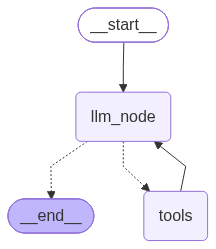

In [40]:
# Visualize compiled StateGraph architecture using Mermaid PNG
from IPython.display import Image, display
display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

<a id="7-multi-step-execution--reasoning-acting-trace"></a>
## 7. Multi-Step Execution & Reasoning-Acting Trace

Test the compiled ReAct agent on a multi-step mathematical problem requiring sequential tool execution: `((25 + 15) * 4 - 60) / 5 ^ 2`.

In [46]:
# ============================================================
# 15. TEST QUESTION
# ============================================================

question = """

Perform the following calculation step by step.

1. Add 10 and 20.
2. Multiply the result by 3.
3. Subtract 15 from the result.
4. Divide the result by 5.
5. Raise the final result to the power of 2.

You must use the corresponding tool for every step.

"""

In [42]:
# Simple conversational test prompt
question = "Hi, how are you?"

In [48]:
# Complex multi-step mathematical calculation test prompt
question="""Perform these operations step by step:

1. Add 25 and 15.
2. Multiply the result by 4.
3. Subtract 60 from the result.
4. Divide the result by 5.
5. Raise the final result to the power of 2.

Use the appropriate tool for every operation.
"""

In [49]:
# # ============================================================
# # 16. INVOKE REACT AGENT
# # ============================================================

result = app.invoke({"messages": [HumanMessage(content=question)]})

In [50]:
# Inspect raw result dictionary from graph execution
result

{'messages': [HumanMessage(content='Perform these operations step by step:\n\n1. Add 25 and 15.\n2. Multiply the result by 4.\n3. Subtract 60 from the result.\n4. Divide the result by 5.\n5. Raise the final result to the power of 2.\n\nUse the appropriate tool for every operation.\n', additional_kwargs={}, response_metadata={}, id='3d7b810f-14e8-44ff-a8fd-7362e94a925f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to perform step by step, using tools. We must call add first: 25+15. Then multiply by 4. Then subtract 60. Then divide by 5. Then power 2. We must use tool calls sequentially, waiting for each result. We'll produce tool calls.", 'tool_calls': [{'id': 'fc_5c7d50c0-1275-457e-8b21-032e95fb3c23', 'function': {'arguments': '{"a":25,"b":15}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 429, 'total_tokens': 518, 'completion_time': 0.100613029, 'completion_tokens_details': {'reasoning

<a id="71-formatted-execution-trajectory-inspection"></a>
### 7.1 Formatted Execution Trajectory Inspection
Iterate through `result["messages"]` to inspect every step in the ReAct execution trajectory.

In [51]:
# ============================================================
# 17. PRINT COMPLETE EXECUTION
# ============================================================

for i, message in enumerate(result["messages"], start=1):
    print("=" * 70)
    print(f"MESSAGE {i}: {message.__class__.__name__}")
    print("=" * 70)

    # AI MESSAGE
    if isinstance(message, AIMessage):
        if message.tool_calls:
            print("TOOL CALLS:")
            for call in message.tool_calls:
                print(f"  • Tool Name: {call['name']}")
                print(f"    Arguments: {call['args']}")

        if message.content:
            print(f"Content: {message.content}")

    # TOOL MESSAGE
    elif isinstance(message, ToolMessage):
        tool_name = getattr(message, "name", "Tool")
        print(f"Tool Result ({tool_name}): {message.content}")

    # HUMAN MESSAGE
    else:
        print(f"User Input: {message.content}")

    print()  # Blank line for visual separation

MESSAGE 1: HumanMessage
User Input: Perform these operations step by step:

1. Add 25 and 15.
2. Multiply the result by 4.
3. Subtract 60 from the result.
4. Divide the result by 5.
5. Raise the final result to the power of 2.

Use the appropriate tool for every operation.


MESSAGE 2: AIMessage
TOOL CALLS:
  • Tool Name: add
    Arguments: {'a': 25, 'b': 15}

MESSAGE 3: ToolMessage
Tool Result (add): 40.0

MESSAGE 4: AIMessage
TOOL CALLS:
  • Tool Name: multiply
    Arguments: {'a': 40, 'b': 4}

MESSAGE 5: ToolMessage
Tool Result (multiply): 160.0

MESSAGE 6: AIMessage
TOOL CALLS:
  • Tool Name: subtract
    Arguments: {'a': 160, 'b': 60}

MESSAGE 7: ToolMessage
Tool Result (subtract): 100.0

MESSAGE 8: AIMessage
TOOL CALLS:
  • Tool Name: divide
    Arguments: {'a': 100, 'b': 5}

MESSAGE 9: ToolMessage
Tool Result (divide): 20.0

MESSAGE 10: AIMessage
TOOL CALLS:
  • Tool Name: power
    Arguments: {'base': 20, 'exponent': 2}

MESSAGE 11: ToolMessage
Tool Result (power): 400.0

MESSA

<a id="72-final-output-display"></a>
### 7.2 Final Output Display

In [52]:
# # ============================================================
# # 18. FINAL ANSWER
# # ============================================================

print("\n")
print("=" * 70)
print("FINAL ANSWER")
print("=" * 70)

print(result["messages"][-1].content)



FINAL ANSWER
Step-by-step calculation:

1. **Add 25 and 15** → 40  
2. **Multiply the result by 4** → 160  
3. **Subtract 60 from the result** → 100  
4. **Divide the result by 5** → 20  
5. **Raise the final result to the power of 2** → 400  

**Final answer: 400**


<a id="8-deep-dive-under-the-hood-of-tools_condition--aimessage"></a>
## 8. Deep-Dive: Under the Hood of `tools_condition` & `AIMessage`

<a id="81-how-tools_condition-works-under-the-hood"></a>
### 8.1 How `tools_condition` Works Under the Hood

`tools_condition` is a prebuilt LangGraph conditional routing function. It inspects the last message in `state["messages"]` to determine the next graph edge:

```python
def tools_condition(
    state: list[AnyMessage] | dict[str, Any] | BaseModel,
    messages_key: str = "messages",
) -> Literal["tools", "__end__"]:
    
    # 1. Extract the last message from graph state
    if isinstance(state, list):
        ai_message = state[-1]
    elif (isinstance(state, dict) and (messages := state.get(messages_key, []))) or (
        messages := getattr(state, messages_key, [])
    ):
        ai_message = messages[-1]
    else:
        msg = f"No messages found in input state to tool_edge: {state}"
        raise ValueError(msg)
        
    # 2. Check if AIMessage contains pending tool calls
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"      # Route to ToolNode
    return "__end__"        # Route to END node
```

---

<a id="82-anatomical-structure-of-aimessage-with-tool_calls"></a>
### 8.2 Anatomical Structure of `AIMessage` with `tool_calls`

When the LLM decides to invoke a tool, it outputs an `AIMessage` containing a structured `tool_calls` payload:

```json
AIMessage(
  content="",
  tool_calls=[
    {
      "name": "weather_callable",
      "args": {"location": "Bangalore"},
      "id": "fc_e0f39f89-bb1b-4d08-a690-088d78053964",
      "type": "tool_call"
    }
  ],
  response_metadata={
    "token_usage": {"prompt_tokens": 126, "completion_tokens": 33, "total_tokens": 159},
    "finish_reason": "tool_calls",
    "model_name": "openai/gpt-oss-20b"
  }
)
```

> **Key Rule:** If `len(ai_message.tool_calls) > 0`, `tools_condition` routes execution to `ToolNode`. Once all tool calls are resolved and the model returns an `AIMessage` with `tool_calls=[]`, `tools_condition` returns `"__end__"`, completing the graph run.

<a id="9-deterministic-react-agent-via-pydantic-tool-registry"></a>
## 9. Deterministic ReAct Agent via Pydantic Tool Registry

While standard tool-calling agents rely on `bind_tools()`, enterprise architectures often require **strict deterministic action planning**.

### Key Architecture Components:

- **Pydantic Decision Schema (`NextAction`)**: Forces the LLM via `llm.with_structured_output(NextAction)` to return an explicit structured action decision (`action`, `x`, `y`, `reason`, `final_answer`).
- **Tool Registry Dictionary (`TOOL_REGISTRY`)**: Maps action strings directly to Python tool functions (`TOOL_REGISTRY = {"add": add, "multiply": multiply, ...}`).
- **Custom TypedDict State (`AgentState`)**: Tracks explicit execution state (`question`, `action`, `x`, `y`, `last_result`, `history`, `steps`).

```text
                               START
                                 │
                                 ▼
                          [Planner Node]
                      (Structured Pydantic Output)
                                 │
                          planner_router
                           /          \
                  (execute) /            \ (finish)
                           ▼              ▼
                   [Tool Executor]   [Final Node]
                    (TOOL_REGISTRY)       │
                           │              ▼
                           └──► Loop back    END
                                to Planner
```

In [ ]:
# ============================================================
# LANGGRAPH AGENT USING TOOL REGISTRY
# ============================================================

from dotenv import load_dotenv
load_dotenv()


# ============================================================
# 1. IMPORTS
# ============================================================

from typing import Literal
from typing_extensions import TypedDict

from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.tools import tool

from langgraph.graph import (
    StateGraph,
    START,
    END,
)


# ============================================================
# 2. CREATE TOOLS
# ============================================================


@tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b


@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b


@tool
def subtract(a: float, b: float) -> float:
    """Subtract b from a."""
    return a - b


@tool
def divide(a: float, b: float) -> float:
    """Divide a by b."""

    if b == 0:
        raise ValueError(
            "Division by zero is not allowed."
        )

    return a / b


@tool
def power(
    base: float,
    exponent: float
) -> float:
    """Raise base to exponent."""

    return base ** exponent


# ============================================================
# 3. TOOL REGISTRY
# ============================================================

TOOL_REGISTRY = {

    "add":
        add,

    "multiply":
        multiply,

    "subtract":
        subtract,

    "divide":
        divide,

    "power":
        power,
}


# ============================================================
# 4. LLM
# ============================================================

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)


# ============================================================
# 5. PYDANTIC STRUCTURED DECISION
# ============================================================

class NextAction(BaseModel):

    action: Literal[
        "add",
        "multiply",
        "subtract",
        "divide",
        "power",
        "finish"
    ] = Field(
        description=(
            "The next operation that must be executed."
        )
    )

    x: float | None = Field(
        default=None,
        description=(
            "First argument. "
            "For power this is the base."
        )
    )

    y: float | None = Field(
        default=None,
        description=(
            "Second argument. "
            "For power this is the exponent."
        )
    )

    reason: str = Field(
        description=(
            "Brief reason for choosing this action."
        )
    )

    final_answer: float | None = Field(
        default=None,
        description=(
            "Final numerical answer when action is finish."
        )
    )


# LLM can ONLY return this structure

planner_model = llm.with_structured_output(
    NextAction
)


# ============================================================
# 6. LANGGRAPH STATE
# ============================================================

class AgentState(TypedDict, total=False):

    question: str

    action: str

    x: float

    y: float

    reason: str

    last_result: float

    final_answer: float

    history: list[dict]

    steps: int


# ============================================================
# 7. PLANNER NODE
# ============================================================

def planner_node(
    state: AgentState
):

    history = state.get(
        "history",
        []
    )

    history_text = ""

    for index, item in enumerate(
        history,
        start=1
    ):

        history_text += (
            f"\nStep {index}: "
            f"{item['tool']} "
            f"with arguments "
            f"{item['args']} "
            f"returned "
            f"{item['result']}"
        )


    prompt = f"""

You are a mathematical workflow planner.

Your job is ONLY to decide the NEXT operation.

Available operations:

add
multiply
subtract
divide
power
finish


Original user request:

{state["question"]}


Already completed operations:

{history_text if history_text else "None"}


Last result:

{state.get("last_result", "None")}


Rules:

1. Follow the user's requested operation order exactly.

2. Execute only ONE operation at a time.

3. If an operation depends on the previous result,
   use the last result as x.

4. For add:
   x = first number
   y = second number

5. For multiply:
   x = first number
   y = second number

6. For subtract:
   result = x - y

7. For divide:
   result = x / y

8. For power:
   x = base
   y = exponent

9. Never perform calculations yourself.

10. When every requested operation has been executed,
    return action="finish".

"""

    decision = planner_model.invoke(
        prompt
    )


    print("\n" + "=" * 60)

    print(
        "PLANNER DECISION"
    )

    print("=" * 60)

    print(
        "Action:",
        decision.action
    )

    print(
        "x:",
        decision.x
    )

    print(
        "y:",
        decision.y
    )

    print(
        "Reason:",
        decision.reason
    )


    result = {

        "action":
            decision.action,

        "reason":
            decision.reason,
    }


    if decision.x is not None:
        result["x"] = decision.x


    if decision.y is not None:
        result["y"] = decision.y


    if decision.final_answer is not None:

        result["final_answer"] = (
            decision.final_answer
        )


    return result


# ============================================================
# 8. ROUTER
# ============================================================

def planner_router(
    state: AgentState
) -> Literal[
    "execute",
    "finish"
]:

    if state["action"] == "finish":

        return "finish"

    return "execute"


# ============================================================
# 9. TOOL EXECUTOR NODE
# ============================================================

def tool_executor_node(
    state: AgentState
):

    action = state["action"]

    x = state["x"]

    y = state["y"]


    # --------------------------------------------------------
    # THIS IS THE IMPORTANT PART
    # --------------------------------------------------------

    selected_tool = TOOL_REGISTRY[
        action
    ]


    print("\nSelected from TOOL_REGISTRY:")

    print(
        selected_tool.name
    )


    # --------------------------------------------------------
    # Prepare correct arguments
    # --------------------------------------------------------

    if action == "power":

        arguments = {

            "base":
                x,

            "exponent":
                y,
        }

    else:

        arguments = {

            "a":
                x,

            "b":
                y,
        }


    # --------------------------------------------------------
    # Execute exact selected tool
    # --------------------------------------------------------

    result = selected_tool.invoke(
        arguments
    )


    print(
        "Arguments:",
        arguments
    )

    print(
        "Tool Result:",
        result
    )


    # --------------------------------------------------------
    # Maintain history
    # --------------------------------------------------------

    history = state.get(
        "history",
        []
    ).copy()


    history.append({

        "tool":
            action,

        "args":
            arguments,

        "result":
            result,
    })


    return {

        "last_result":
            float(result),

        "history":
            history,

        "steps":
            state.get(
                "steps",
                0
            ) + 1
    }


# ============================================================
# 10. FINAL NODE
# ============================================================

def final_node(
    state: AgentState
):

    # We trust actual executed tool result,
    # not an LLM-calculated answer.

    final_answer = state.get(
        "last_result"
    )


    print("\n" + "=" * 60)

    print(
        "FINAL ANSWER:",
        final_answer
    )

    print("=" * 60)


    return {

        "final_answer":
            final_answer
    }


# ============================================================
# 11. CREATE GRAPH
# ============================================================

workflow = StateGraph(
    AgentState
)


# ============================================================
# 12. ADD NODES
# ============================================================

workflow.add_node(
    "planner",
    planner_node
)


workflow.add_node(
    "tool_executor",
    tool_executor_node
)


workflow.add_node(
    "final",
    final_node
)


# ============================================================
# 13. EDGES
# ============================================================

workflow.add_edge(
    START,
    "planner"
)


workflow.add_conditional_edges(

    "planner",

    planner_router,

    {
        "execute":
            "tool_executor",

        "finish":
            "final",
    }
)


# After every tool:
#
# Tool -> Planner
#
# Planner decides next operation.

workflow.add_edge(
    "tool_executor",
    "planner"
)


workflow.add_edge(
    "final",
    END
)


# ============================================================
# 14. COMPILE
# ============================================================

app = workflow.compile()


# ============================================================
# 15. VISUALIZE
# ============================================================

from IPython.display import (
    Image,
    display
)


display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)


# ============================================================
# 16. TEST
# ============================================================

question = """

Perform these calculations in order:

1. Add 10 and 20.
2. Multiply the result by 3.
3. Subtract 15 from the result.
4. Divide the result by 5.
5. Raise the result to the power of 2.

"""


result = app.invoke(

    {

        "question":
            question,

        "history":
            [],

        "steps":
            0,
    },

    config={
        "recursion_limit":
            20
    }
)


# ============================================================
# 17. RESULT
# ============================================================

print("\nEXECUTION HISTORY")

for step in result["history"]:

    print(step)


print(
    "\nFINAL:",
    result["final_answer"]
)